### 1-1. midi 파일 전처리

In [134]:
from preprocess import adjust_to_eighth_note

file_name = "Ryuichi_Sakamoto_-_hibari.mid"
adjusted_notes = adjust_to_eighth_note(file_name)

adn_1 = adjusted_notes[:2006]
adn_2 = adjusted_notes[2006:]

adn_1_real = adn_1[:-59]
adn_2_real = adn_2[59:]

1th instrument ending : index 2006
2th instrument ending : index 3953


c:\Users\82104\Developments\.venv\lib\site-packages\pretty_midi\pretty_midi.py:100: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


* adn_i_chord_(i = 1, 2)는 두 list에서 동시에 연주되는 범위(5~132마디)에 해당됩니다.

In [ ]:
from preprocess import label_active_chord_by_onset

adn_1_chord = label_active_chord_by_onset(adn_1_real)
adn_2_chord = label_active_chord_by_onset(adn_2_real)

adn_1_chord_ = adn_1_chord[33:] 
adn_2_chord_ = adn_2_chord[:-32]

chord_1_132 = adn_1_chord.copy()
chord_2_132 = [None, *adn_2_chord]
# each of which is of length 1056 (132 bars)

# chord_1_132는 규칙적으로 반복되므로 굳이 solo 파트를 뒤로 붙이지 않아도
# chord_2_132와 원형적 alignness를 보고자 할 때 가능하다.

adn_1_chord_ = chord_1_132[:-32]
adn_2_chord_ = chord_2_132[:-32]

adn_1_whole_c = [*adn_1_chord, *([None] * 32)]
adn_2_whole_c = [*([None] * 32), *chord_2_132]

In [4]:
# import pandas as pd
# module_chord_label = pd.DataFrame(adn_1_chord[:32])
# module_chord_label.value_counts().to_frame()

* 곡에서 반복되는 단위를 추출하고(module_notes), 각 시점에서 활성화된 음들을 모아(active_module) 화음 단위로 정제합니다.
* 화음에 대해 3가지 방식으로 딕셔너리를 만듭니다.

In [ ]:
from preprocess import (group_notes_with_duration_, notes_label_n_counts, 
                  chord_label_to_note_labels, transform_dict, chord_label_dict)

module_notes = adn_1_real[:59]
# module_chord = adn_1_chord[:32]
active_module = group_notes_with_duration_(module_notes)

notes_label, notes_counts = notes_label_n_counts(module_notes)
chord_label = chord_label_dict(active_module)

# notes = (pitch, duration)
notes_dict = chord_label_to_note_labels(chord_label, notes_label)
pitches_dict = transform_dict(chord_label)
pitch_classes_dict = transform_dict(chord_label, project=True)

* 총 17개의 화음이 등장하고, 각 instrumental의 솔로 구간이 있어 17 choose 2 + 17 = 153개의 조합이 등장할 거란 예상처럼 0 ~ 152까지의 value가 발견됩니다.

In [139]:
from preprocess import simul_chord_lists, label_simul_chords_combi

simul_chords_key = simul_chord_lists(adn_1_chord_, adn_2_chord_)
simul_chord_comb_dict = label_simul_chords_combi(simul_chords_key)

# for item_set, label in simul_chord_comb_dict.items():
#     print(f"{set(item_set)}: {label}")

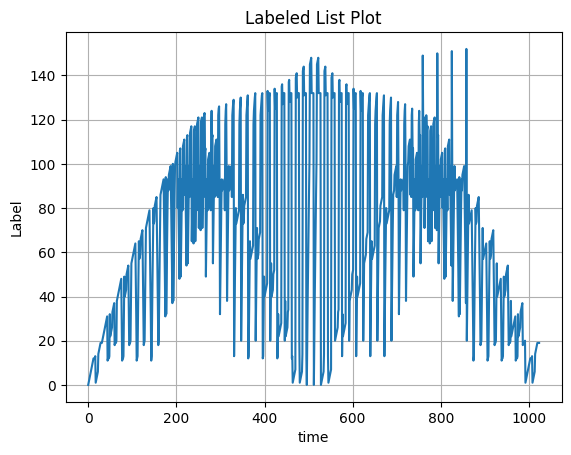

In [138]:
import matplotlib.pyplot as plt

# simul_chord_comb_dict
labeled_list = []
for sublist in simul_chords_key:
    key = frozenset(sublist)  # 현재 sublist를 frozenset으로 변환
    label = simul_chord_comb_dict[key]  # 해당 frozenset을 키로 사용하여 label 가져오기
    labeled_list.append(label)  # label을 labeled_list에 추가

# x축 데이터 (index) 생성
x = list(range(len(labeled_list)))

# 그래프 생성
plt.plot(x, labeled_list, linestyle='-')  # marker와 linestyle을 지정하여 꺾은선 그래프 생성

# marker='o',

# 그래프 제목 및 축 레이블 설정
plt.title("Labeled List Plot")
plt.xlabel("time")
plt.ylabel("Label")

# 그리드 추가 (선택 사항)
plt.grid(True)

# 그래프 출력
plt.show()

In [9]:
from collections import Counter

# Counter 객체 생성
label_counts = Counter(labeled_list)

frequent_labels = []
often_labels = []
for label, count in label_counts.items():
    if count >= 20 :
        # print(f"Label {label}: {count}번")
        frequent_labels.append(label)
    elif count >= 8 : # 8 아니면 10
        often_labels.append(label)

In [10]:
# frequent_chord_comb = [key for key, value in simul_chord_comb_dict.items() if value in frequent_labels]
often_chord_comb = [key for key, value in simul_chord_comb_dict.items() if value in often_labels]

# label 빈도를 저장할 딕셔너리 초기화
label_counts = {i: 0 for i in range(17)}  # 0부터 16까지 label 초기화

# label 빈도 계산
for chord_comb in often_chord_comb:
    for label in chord_comb:
        # if 0 <= label <= 16:
        label_counts[label] += 1

# 결과 출력
print("Label Counts:")
for label, count in label_counts.items():
    print(f"Label {label}: {count}번")

Label Counts:
Label 0: 6번
Label 1: 6번
Label 2: 6번
Label 3: 6번
Label 4: 6번
Label 5: 6번
Label 6: 6번
Label 7: 2번
Label 8: 2번
Label 9: 2번
Label 10: 2번
Label 11: 8번
Label 12: 2번
Label 13: 2번
Label 14: 2번
Label 15: 2번
Label 16: 8번


* 밑에 있는 search_optimal_rate_n_dict 함수에 쓰일 intra_weights와 inter_weight를 구하고, plot에 쓰기 위해 각 딕셔너리의 이름을 추가합니다.

In [12]:
notes_dict['name'] = 'notes_dict'
pitches_dict['name'] = 'pitches_dict'
pitch_classes_dict['name'] = 'pitch_classes_dict'

* 밑에 search_optimal_rate_n_dict에서 rate_end를 1.5로 설정한 것이 임의가 아님에 대한 설명 요망
* 1(np.inf 대신 넣어놓은)보다 작은 distance 값이 0.5인데, 애초에 1을 np.inf 대신 넣어놓은 만큼
* rate가 변함에 따라 해당 edge를 포함한 삼각형 이상의 simplex가 나오지 않도록 설정해야 함.

In [13]:
"""
listofDimension
[1, 2, 3] : 33.2s
[1] : 0.1s
[2] : 2.2s /   '(5, 18, 19) - (9, 18, 19) + (3, 5, 19) - (3, 9, 19) + (5, 11, 18) - (9, 11, 18) - (3, 5, 11) + (3, 9, 11)']]
[3] : 36.7s /   '-(0, 5, 9, 13) + (3, 5, 9, 13) + (2, 3, 9, 13) + (0, 5, 7, 13) - (3, 5, 7, 13) - (2, 3, 7, 13) + (0, 5, 9, 10) - (3, 5, 9, 10) - (2, 3, 9, 10) - (0, 5, 7, 10) + (3, 5, 7, 10) + (2, 3, 7, 10) + (0, 1, 9, 13) + (1, 2, 9, 13) - (0, 1, 9, 10) - (1, 2, 9, 10) - (0, 1, 7, 13) - (1, 2, 7, 13) + (0, 1, 7, 10) + (1, 2, 7, 10)']]
[1, 2] : 2.1s
[2, 3] : 33.6s
"""

print("generateBarcode 실행결과")

generateBarcode 실행결과


### 1-2. 거리행렬 기반 사이클 분석

In [ ]:
# import util
# import importlib
# importlib.reload(util)
from util import search_timeflow_cycles, get_rBD_groupedBy_cycle, plot_cycle_BirthDeath_over_rate, split_cycles_by_consecutive

In [ ]:
cycles_profile_t_n1, outta_reach_t_n1 = search_timeflow_cycles(adn_1_chord_, adn_2_chord_, inter_lag = 1, refine_dict = notes_dict)

cycle_persistence_t_n1 = get_rBD_groupedBy_cycle(cycles_profile_t_n1)
print("Total number of cycles: ", len(cycle_persistence_t_n1))

non_consecutive_cycles_t_n1, consecutive_cycles_t_n1 = split_cycles_by_consecutive(cycle_persistence_t_n1, out_of_reach = outta_reach_t_n1, step = 0.01)
plot_cycle_BirthDeath_over_rate(non_consecutive_cycles_t_n1, subplot_in_a_row = 3)
plot_cycle_BirthDeath_over_rate(consecutive_cycles_t_n1, subplot_in_a_row = 4)

In [ ]:
cycles_profile_t_n2, outta_reach_t_n2 = search_timeflow_cycles(adn_1_chord_, adn_2_chord_, inter_lag = 2, refine_dict = notes_dict)

cycle_persistence_t_n2 = get_rBD_groupedBy_cycle(cycles_profile_t_n2)
print("Total number of cycles: ", len(cycle_persistence_t_n2))

non_consecutive_cycles_t_n2, consecutive_cycles_t_n2 = split_cycles_by_consecutive(cycle_persistence_t_n2, out_of_reach = outta_reach_t_n2, step = 0.01)
plot_cycle_BirthDeath_over_rate(non_consecutive_cycles_t_n2, subplot_in_a_row = 3)
plot_cycle_BirthDeath_over_rate(consecutive_cycles_t_n2, subplot_in_a_row = 4)

In [133]:
non_consecutive_cycles_t_n2

{(0, 15, 22, 1): ((0.0, 0.007936507936507936, 101.0),
  (0.01, 0.007926442612555486, 2.5),
  (0.02, 0.007916402786573781, 1.25),
  (0.04, 0.007896399241945674, 0.625),
  (0.05, 0.007886435331230283, 0.5),
  (0.07, 0.007866582756450597, 0.3571428571428571),
  (0.08, 0.00785669390320553, 0.3125),
  (0.09, 0.007846829880728186, 0.2777777777777778),
  (0.1, 0.007836990595611286, 0.25),
  (0.11, 0.007827175954915467, 0.22727272727272727),
  (0.13, 0.007807620237351654, 0.1923076923076923),
  (0.14, 0.0077978789769182775, 0.17857142857142855),
  (0.15, 0.00778816199376947, 0.16666666666666666),
  (0.16, 0.007778469197261979, 0.15625),
  (0.17, 0.007768800497203232, 0.14705882352941174),
  (0.18, 0.007759155803848542, 0.1388888888888889),
  (0.19, 0.007749535027898327, 0.13157894736842105),
  (0.2, 0.007739938080495357, 0.125),
  (0.21, 0.0077303648732220155, 0.11904761904761904),
  (0.22, 0.007720815318097591, 0.11363636363636363),
  (0.23, 0.0077112893275755705, 0.10869565217391303),
  (0.2

In [ ]:
cycles_profile_t_n3, outta_reach_t_n3 = search_timeflow_cycles(adn_1_chord_, adn_2_chord_, inter_lag = 3, refine_dict = notes_dict)

cycle_persistence_t_n3 = get_rBD_groupedBy_cycle(cycles_profile_t_n3)
print("Total number of cycles: ", len(cycle_persistence_t_n3))

non_consecutive_cycles_t_n3, consecutive_cycles_t_n3 = split_cycles_by_consecutive(cycle_persistence_t_n3, out_of_reach = outta_reach_t_n3)
plot_cycle_BirthDeath_over_rate(non_consecutive_cycles_t_n3, subplot_in_a_row = 3)
plot_cycle_BirthDeath_over_rate(consecutive_cycles_t_n3, subplot_in_a_row = 4)

In [82]:
cycles_t_n1 = []
for cycle in cycle_persistence_t_n1.keys():
    cycles_t_n1.append(cycle)
cycles_t_n1 = set(cycles_t_n1)

cycles_t_n2 = []
for cycle in cycle_persistence_t_n2.keys():
    cycles_t_n2.append(cycle)
cycles_t_n2 = set(cycles_t_n2)

cycles_t_n3 = []
for cycle in cycle_persistence_t_n3.keys():
    cycles_t_n3.append(cycle)
cycles_t_n3 = set(cycles_t_n3)

In [110]:
cycles_t_n12 = cycles_t_n1.intersection(cycles_t_n2)
cycles_t_n23 = cycles_t_n2.intersection(cycles_t_n3)
cycles_t_n13 = cycles_t_n1.intersection(cycles_t_n3)

cycles_t_n123 = cycles_t_n12.intersection(cycles_t_n3)
print(f"Lag 1, 2, 3 모두에서 발견되는 사이클 : {cycles_t_n123}")

Lag 1, 2, 3 모두에서 발견되는 사이클 : {(2, 9, 12, 5, 3), (0, 6, 9, 1), (0, 13, 8, 15), (5, 10, 9, 11), (3, 9, 16, 5), (0, 13, 9, 14, 16), (5, 13, 9, 11), (0, 19, 22, 1), (5, 11, 9, 18), (0, 15, 8, 18), (5, 11, 9, 15), (2, 9, 10, 5, 3), (0, 13, 9, 14, 18, 5), (0, 15, 22, 1), (0, 6, 9, 10, 5), (0, 5, 18, 19, 22, 1), (0, 6, 17, 1), (0, 5, 18, 14, 9, 13), (0, 5, 10, 9, 1), (5, 12, 9, 10), (5, 6, 9, 16), (0, 1, 9, 11, 5), (5, 10, 9, 13), (2, 9, 16, 5, 3), (5, 11, 9, 18, 19), (2, 9, 13, 5, 3), (5, 16, 14, 18), (2, 3, 5, 6, 9), (2, 20, 17, 6, 5, 18), (3, 9, 13, 5), (0, 1, 22, 15), (5, 10, 9, 18, 8, 15), (0, 1, 2, 18, 5), (3, 9, 10, 5), (5, 6, 9, 12), (5, 6, 9, 15), (5, 10, 9, 12), (5, 10, 9, 18), (5, 11, 9, 13), (2, 9, 11, 5, 3), (5, 11, 9, 10), (8, 13, 9, 15), (3, 9, 12, 5)}


In [109]:
print(f"Lag 2, 3에서 발견되고 1에서 발견되지 않는 사이클 : {cycles_t_n23 - cycles_t_n123}")
print(f"Lag 1, 3에서 발견되고 2에서 발견되지 않는 사이클 : {cycles_t_n13 - cycles_t_n123}")
print(f"Lag 1, 2에서 발견되고 3에서 발견되지 않는 사이클 : {cycles_t_n12 - cycles_t_n123}")

# print("\n")
print(f"Lag 1에서만 발견되는 사이클 : {cycles_t_n1 - cycles_t_n12 - cycles_t_n13}")
print(f"Lag 2에서만 발견되는 사이클 : {cycles_t_n2 - cycles_t_n12 - cycles_t_n23}")
print(f"Lag 3에서만 발견되는 사이클 : {cycles_t_n3 - cycles_t_n13 - cycles_t_n23}")

Lag 2, 3에서 발견되고 1에서 발견되지 않는 사이클 : {(0, 13, 9, 14, 16, 5), (5, 18, 14, 9, 13)}
Lag 1, 3에서 발견되고 2에서 발견되지 않는 사이클 : {(0, 6, 21, 1)}
Lag 1, 2에서 발견되고 3에서 발견되지 않는 사이클 : {(3, 9, 14, 16, 5)}
Lag 1에서만 발견되는 사이클 : {(0, 13, 9, 14, 18, 5, 16), (5, 6, 9, 18, 8, 15)}
Lag 2에서만 발견되는 사이클 : {(5, 10, 9, 15), (2, 3, 5, 9)}
Lag 3에서만 발견되는 사이클 : {(5, 16, 9, 14, 18)}


* inter_weight로만 실행했을 때

In [140]:
from util import get_chords_inter_connected, is_distance_matrix_from, generateBarcode, analyze_lifespans

inter_weight = get_chords_inter_connected(adn_1_chord_, adn_2_chord_, lag=1)

oor_inter = 1 + 2 * 1 / inter_weight[inter_weight!=0].min().min() # 2
inter_distance = is_distance_matrix_from(inter_weight, notes_dict, out_of_reach = oor_inter)

birthDeath_inter = generateBarcode(mat = inter_distance.values, exactStep = True, birthDeathSimplex=False, sortDimension=False)
cycle_profile_inter = [(1e+6, birthDeath_inter)]
cycles_info_inter = analyze_lifespans(cycle_profile_inter, out_of_reach = 1)
cycle_persistence_inter = get_rBD_groupedBy_cycle(cycle_profile_inter)

for cycle, rBD in cycle_persistence_inter.items():
    for rate, birth, death in rBD :
        print(f"{cycle} : {round(birth, 6)} - {round(death, 6)}")

(5, 10, 9, 12) : 0.006623 - 0.007353
(5, 10, 9, 13) : 0.007143 - 0.007353
(0, 7, 5, 9) : 0.010638 - 0.01087
(1, 9, 10, 7) : 0.010417 - 0.01087
(6, 9, 10, 7) : 0.010417 - 0.01087
(2, 7, 10, 9, 13) : 0.010417 - 0.011364
(3, 10, 7, 12) : 0.013158 - 0.013889
(0, 4, 2, 7) : 0.010989 - 0.015625
(2, 4, 3, 10, 7) : 0.01087 - 0.015625
(0, 4, 3, 13) : 0.013889 - 0.015625
(1, 4, 2, 7) : 0.01087 - 0.015625
(0, 17, 8, 9) : 0.020833 - 0.025
(0, 9, 8, 21) : 0.03125 - 0.035714
(0, 9, 8, 22) : 0.03125 - 0.035714


In [17]:
simul_cycles = []
for simul_cycle in cycle_persistence_inter.keys():
    simul_cycles.append(simul_cycle)

cycle_persistence_t_n1 = get_rBD_groupedBy_cycle(cycles_profile_t_n1)
timeflow_cycles_n1 = []
for cycle in cycle_persistence_t_n1.keys():
    timeflow_cycles_n1.append(cycle)

set(timeflow_cycles_n1).intersection(set(simul_cycles))

{(5, 10, 9, 12), (5, 10, 9, 13)}

* 생각보다 적게 나온다.

* cycle_profile에 저장되어있는 정보를 딕셔너리로 정제합니다.
* key : 사이클을 구성하는 vertex들을 가장 작은 정수로 레이블링된 것부터 연결된 순서대로 나열
* value : 해당 사이클이 발견된 시점에 대해 (rate, birth, death) tuple를 담은 리스트

* 같은 vertex로 구성되어 있지만 inter_weight와 intra_weight의 비율이 변함에 따라 연결 순서가 달라지는 경우가 5건 관찰됩니다.
* generateBarcode 함수에서 DeathSimplex를 분석하는 기능을 이용해 어떻게 이럴 수 있는지 확인할 예정입니다.
* 2, 3번째 경우는 중간에 해당 Vertices 조합으로 사이클이 나타나지 않는 구간이 있는 반면 1, 4, 5번째 경우는 연속적이어서 DeathSimplex가 동일하지 않을까 예상됩니다.

In [20]:
from util import check_rearranged_cycles

# 동일 Cycle 확인 함수 호출
rearranged_cycles = check_rearranged_cycles(cycle_persistence_t_n1)

Vertex label: (0, 1, 15, 22)
  Cycle: (0, 15, 22, 1), Rate: [0.0]
  Cycle: (0, 1, 22, 15), Rate: [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3, 0.31, 0.32, 0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4, 0.41, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5, 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.57, 0.58, 0.59, 0.6, 0.61, 0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.69, 0.7, 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8, 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88, 0.89, 0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1.0, 1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1, 1.11, 1.12, 1.13, 1.14, 1.15, 1.16, 1.17, 1.18, 1.19, 1.2, 1.21, 1.22, 1.23, 1.24, 1.25, 1.26, 1.27, 1.28, 1.29, 1.3, 1.31, 1.32, 1.33, 1.34, 1.35, 1.36, 1.37, 1.38, 1.39, 1.4, 1.41, 1.42, 1.43, 1.44, 1.45, 1.46, 1.47, 1.48, 1.49]
Vertex label: (5, 9, 1

* 사이클 갯수에 대한 위의 plot은 대강 0.03, 0.5, 0.65, 0.95를 기점으로 계단이 나뉘고 진동을 하고 있었다.

* 아주 잠깐씩 나타나던 (0, 6, 21, 1)은 rate에 따라 BirthDeath는 달라지는데
* 확인해보면 life 길이의 고윳값(eigenvalue X unique() O)이 2개뿐이어서
* 왜 이런지 이해가 필요하다, getBarcode에서 exactStep = True 옵션으로 했는데...

In [111]:
for rBD in cycle_persistence_t_n1[(0, 6, 21, 1)][:5] :
    print(rBD)

(0.03, 0.007883948281299274, 0.007883948281299276)
(0.13, 0.00771366862079605, 0.007713668620796052)
(0.22, 0.007566585956416465, 0.007566585956416467)
(0.24, 0.007534659433393611, 0.007534659433393613)
(0.31, 0.007425007425007425, 0.007425007425007426)


In [210]:
lifes = set()
for i in range(len(cycle_persistence_t_n1[(0, 6, 21, 1)])) :
    # 각 rate에서 death - birth를 계산하는 것
    life = cycle_persistence_t_n1[(0, 6, 21, 1)][i][2] - cycle_persistence_t_n1[(0, 6, 21, 1)][i][1]
    lifes.add(life)
    # print(life)

# print("\n")
print(f"cycle (0, 6, 21, 1) could persist for {len(lifes)} options in terms of its life, ")
print(f"each of which is {lifes}")


cycle (0, 6, 21, 1) could persist for 2 options in terms of its life, 
each of which is {8.673617379884035e-19, 1.734723475976807e-18}


on rate 0.0...
on rate 0.1...
on rate 0.2...
on rate 0.3...
on rate 0.4...
on rate 0.5...
on rate 0.6...
on rate 0.7...
on rate 0.8...
on rate 0.9...
on rate 1.0...
on rate 1.1...
on rate 1.2...
on rate 1.3...
on rate 1.4...


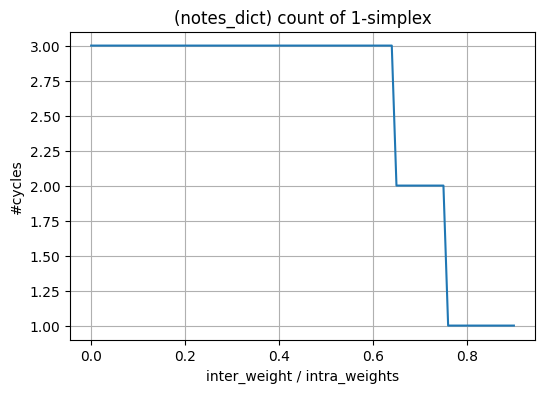

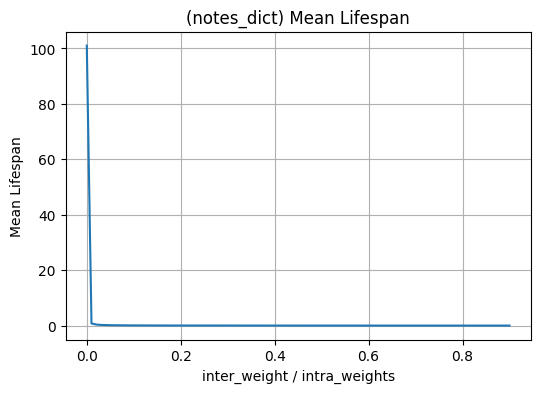

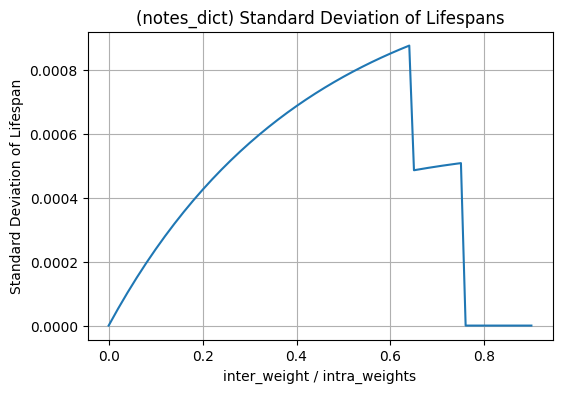

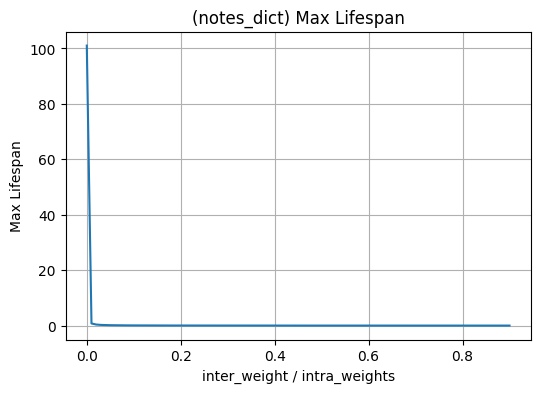

In [174]:
from util import search_simul_cycles

cycles_profile_s, outta_reach_s = search_simul_cycles(adn_1_whole_c, adn_2_whole_c, refine_dict=notes_dict)

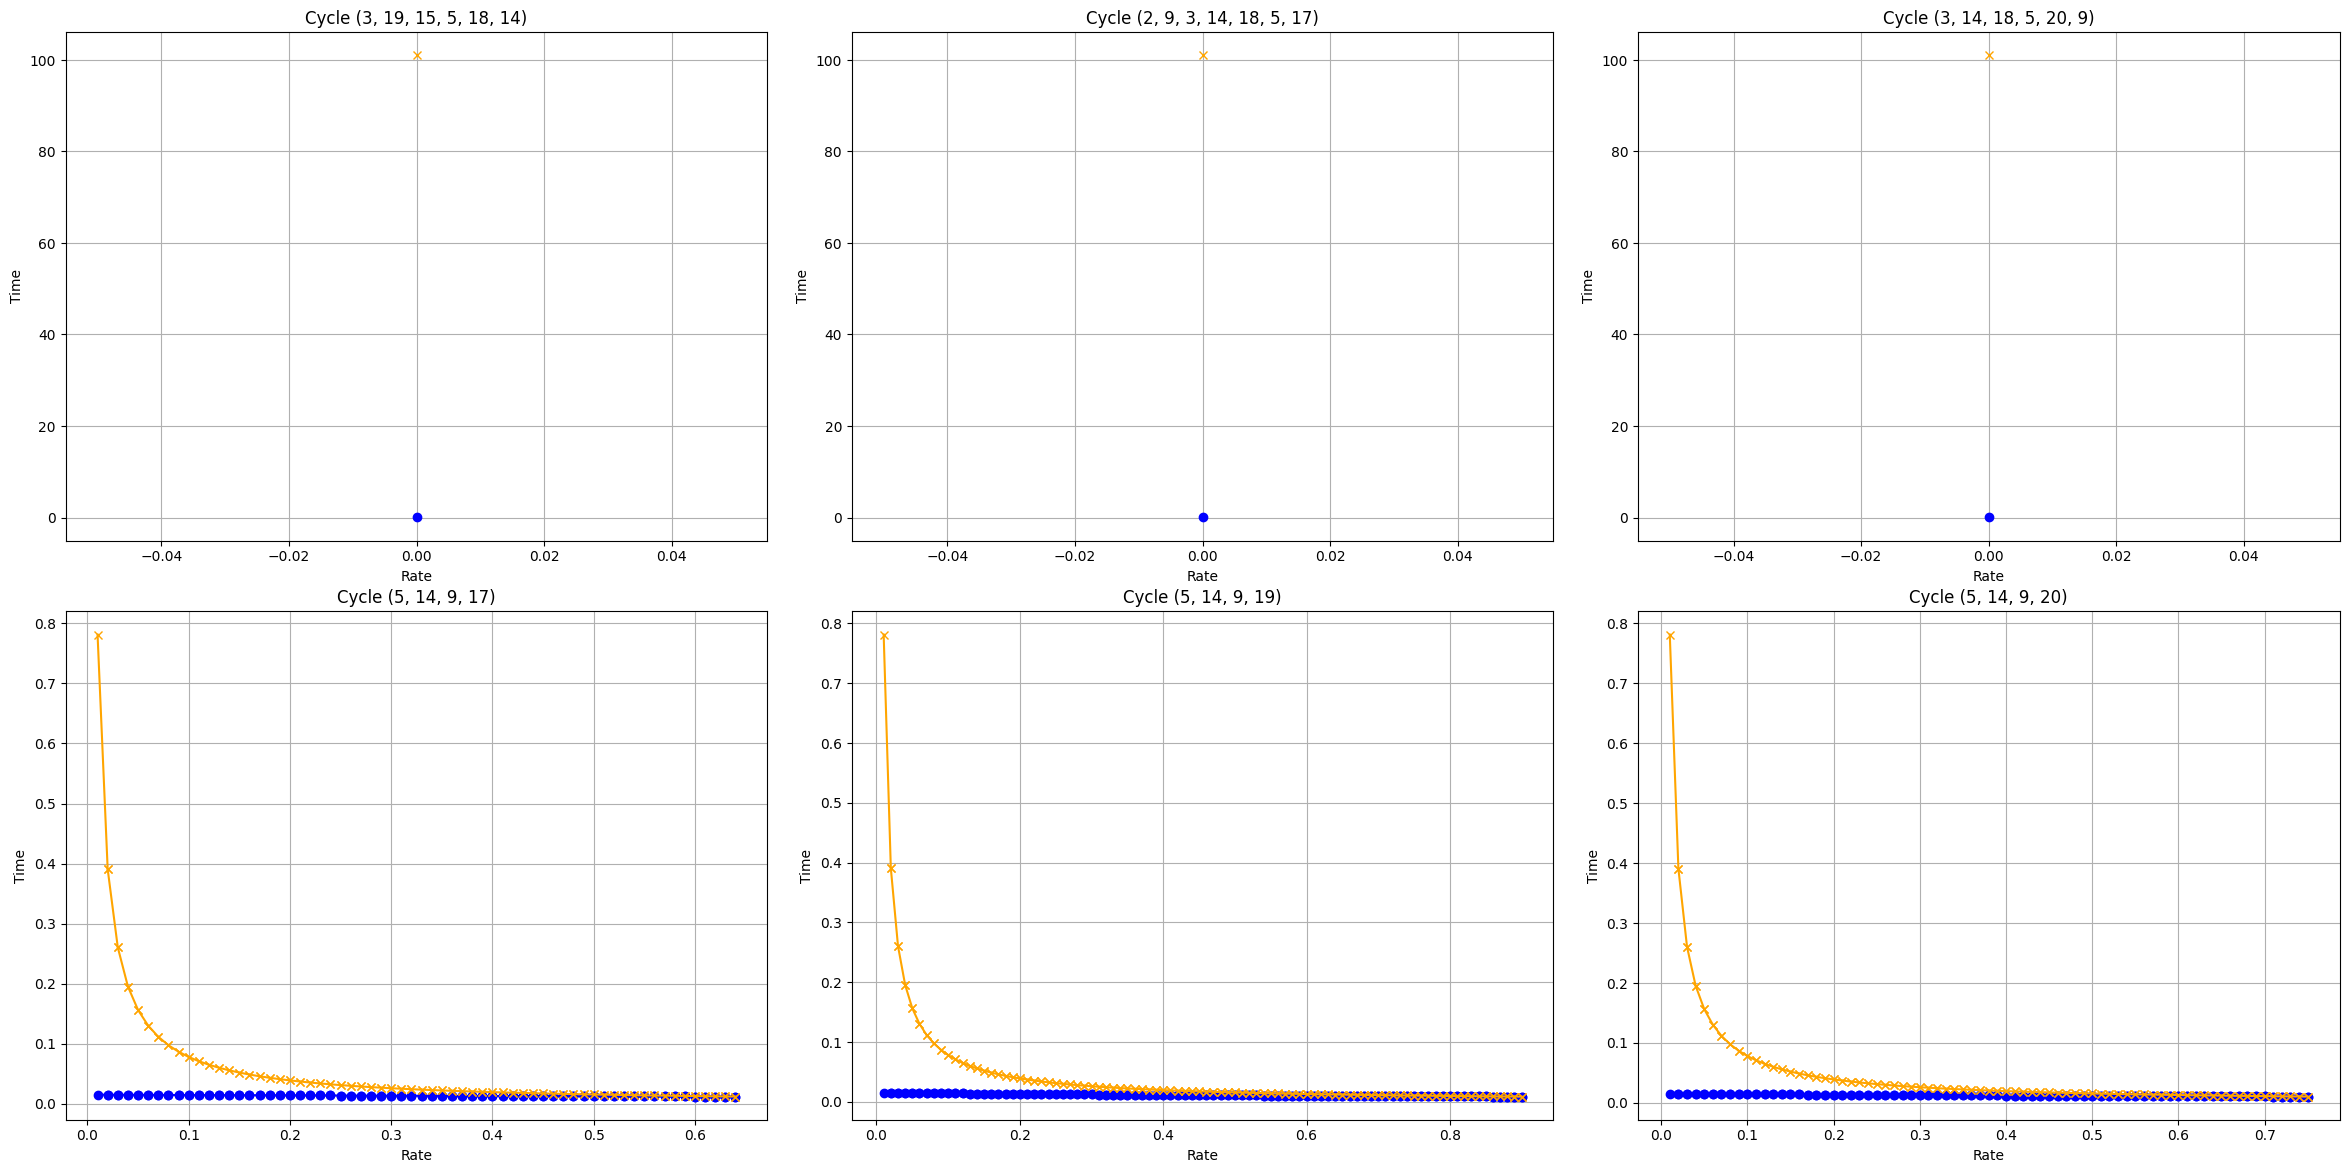

In [ ]:
cycle_persistence_s = get_rBD_groupedBy_cycle(cycles_profile_s)

non_consecutive_cycles_s, consecutive_cycles_s = split_cycles_by_consecutive(cycle_persistence_s, out_of_reach = outta_reach_s, step = 0.01)
plot_cycle_BirthDeath_over_rate(consecutive_cycles_s, subplot_in_a_row = 3)

In [178]:
cycle_persistence_s.keys()

dict_keys([(3, 19, 15, 5, 18, 14), (2, 9, 3, 14, 18, 5, 17), (3, 14, 18, 5, 20, 9), (5, 14, 9, 17), (5, 14, 9, 19), (5, 14, 9, 20)])

* 악보 전체 범위에 대한 Chord labelled list (simul_whole_c)를 만들고, notes_dict를 이용해 note labelling을 해줍니다.
* inst 1은 마지막 4마디에 쉬고, inst 2는 처음 4마디를 쉽니다. 

In [141]:
from preprocess import simul_chord_lists
from util import simul_union_by_dict

simul_whole_c = simul_chord_lists(adn_1_whole_c, adn_2_whole_c)
simul_notes = simul_union_by_dict(simul_whole_c, notes_dict)

print("At First bar, inst 1 playes solo", simul_notes[0:5])
print("At Fifth bar, inst 1 & 2 play   ", simul_notes[32:37])

# print(simul_notes[:32] == simul_notes[-32:]) # True (firth 4 and last 4 bars are played solo)
# print(simul_notes[:33] == simul_notes[-33:]) # False

At First bar, inst 1 playes solo [{9, 15, 6, 1}, {9, 19, 6, 1}, {16, 2, 20, 7}, {2, 23, 7}, {10, 18, 3, 22}]
At Fifth bar, inst 1 & 2 play    [{9, 15, 6, 1}, {1, 6, 9, 15, 19}, {1, 2, 6, 7, 9, 16, 19, 20}, {16, 2, 7, 20, 23}, {18, 3, 2, 7, 22, 23, 10}]


In [147]:
from util import get_correct_df

hibari_notes_df = get_correct_df(notes_dict, simul_notes)
hibari_notes_df

,1,2,3,4,5,6,7,8,9,10,...,14,15,16,17,18,19,20,21,22,23
0,1,0,0,0,0,1,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
1,1,0,0,0,0,1,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
2,0,1,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,1,0,0,0
3,0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1083,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1084,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1085,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1086,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [148]:
from util import label_cycle

cycle_labeled, length_counts, note_counts = label_cycle(cycle_persistence_t_n1, transform_dict = notes_dict, log = True)

Cycle 길이별 개수:
Length 4: 27개
Length 5: 13개
Length 6: 6개
Length 7: 1개

Component별 포함된 사이클 개수:
Note 5: 37개
Note 9: 36개
Note 0: 17개
Note 18: 13개
Note 3: 11개
Note 10: 11개
Note 13: 11개
Note 6: 10개
Note 1: 10개
Note 15: 9개
Note 11: 9개
Note 2: 8개
Note 16: 7개
Note 14: 6개
Note 8: 5개
Note 12: 5개
Note 22: 4개
Note 19: 3개
Note 17: 2개
Note 20: 1개
Note 21: 1개

component label not in any cycle : {4, 23, 7}
where there are 23 components (notes_dict의 경우 인덱스가 1부터 시작합니다)


In [ ]:
from util import get_cycles_scattered_df

# cycle_df 생성
cycles_weak = get_cycles_scattered_df(df = hibari_notes_df, cycle_labeled = cycle_labeled, weak = True)
cycles_strong = get_cycles_scattered_df(df = hibari_notes_df, cycle_labeled = cycle_labeled, weak = False)
cycles_strong.head(7)

,0,1,2,3,4,5,6,7,8,9,...,37,38,39,40,41,42,43,44,45,46
0,{6},"{1, 6}",{1},"{1, 6}","{1, 9}",{1},{1},{6},{6},{6},...,{6},{6},{6},"{1, 6}",{6},{9},"{9, 6}","{9, 6}",{6},{6}
1,"{19, 6}","{1, 19, 6}",{1},"{1, 19, 6}","{1, 19, 9}",{1},{1},{6},"{19, 6}",{6},...,{6},{6},"{19, 6}","{1, 6}",{6},{9},"{9, 19, 6}","{9, 19, 6}",{6},"{19, 6}"
2,{7},{2},"{16, 2}","{2, 20}",{16},"{2, 7}","{2, 7}",{},{20},{16},...,"{16, 7}",{7},{},{2},{7},{16},"{16, 7}",{16},{},{}
3,{7},{2},"{2, 23}","{2, 23}",{},"{2, 7}","{2, 7}",{},{},{},...,{7},{7},{},{2},{7},{},{7},{},{},{}
4,"{18, 3}",{3},{},{},{},{10},{18},"{10, 3}",{10},{10},...,{10},{10},{10},{10},"{10, 3}",{10},{10},{10},{10},{10}
5,"{3, 21}",{3},{},{},{},{10},{},"{10, 3}",{10},{10},...,{10},{10},{10},{10},"{10, 3}",{10},{10},{10},{10},{10}
6,{19},{19},{},{19},{19},{10},{},"{10, 4}","{10, 19}",{10},...,{10},{10},"{10, 19}",{10},"{10, 4}",{10},"{10, 19}","{10, 19}",{10},"{10, 19}"


Correlation between plausible ratio and cycle length: 0.29864992771987947
Correlation between plausible ratio and mean of vertex freq: 0.18062216844614606
Correlation between cycle length and mean of vertex freq: 0.38681109972365124


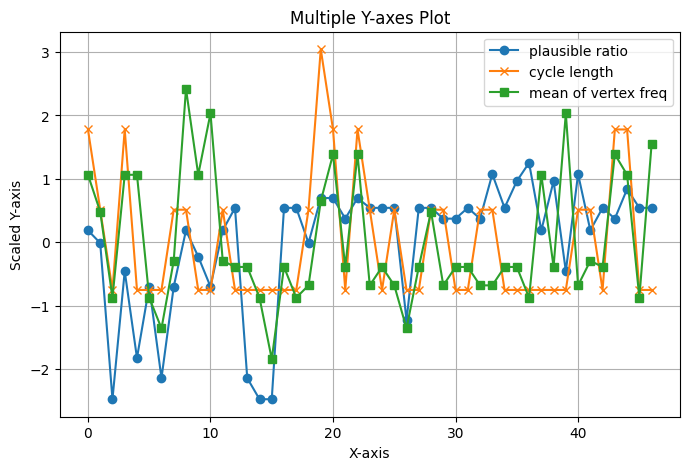

[(0, 0.8455882352941176, 6, 3.5),
 (1, 0.8207720588235294, 5, 3.2),
 (2, 0.5147058823529411, 4, 2.5),
 (3, 0.765625, 6, 3.5),
 (4, 0.5955882352941176, 4, 3.5)]

In [150]:
# 위에도 있는데 너무 멀어서 다시 가져옴
module_notes = adn_1_real[:59]
active_module = group_notes_with_duration_(module_notes)
notes_label, notes_counts = notes_label_n_counts(module_notes)

from util import notes_label_counts, analyze_cycles_scattered #, check_ratio_of_on

notes_freq = notes_label_counts(notes_label, notes_counts)
plausible = analyze_cycles_scattered(cycles_weak, cycle_labeled, notes_freq, scale = True)
plausible[:5] # (column_idx, ratio, cycle_length, average_freq)

In [ ]:
# notes_freq_ = sorted(notes_freq.items(), key=lambda item: item[1])
# notes_freq_

* 실제로 등장하는지 판단할 수치적인 기준?
* 시각화할 방법 : 전부 등장하는 구간 몇 개 골라서 색칠해놓기
* 어느 사이클에도 포함되지 않은 녀석들의 모듈 내 빈도수와 몇 번 화음에 포함되어 있는지

In [158]:
from util import check_cycle_if_plausible

ith_cycle_scattered, cycle_name = check_cycle_if_plausible(cycles_strong, column_idx = 0, cycle_labeled = cycle_labeled, 
                                                           notes_counts = notes_counts, notes_label = notes_label)
ith_cycle_scattered

label: 19, 등장횟수: 6
label: 21, 등장횟수: 4
label: 6, 등장횟수: 4
label: 18, 등장횟수: 3
label: 3, 등장횟수: 2
label: 7, 등장횟수: 2


,"[3, 21, 18, 7, 6, 19]"
0,{6}
1,"{19, 6}"
2,{7}
3,{7}
4,"{18, 3}"
...,...
1078,{19}
1079,{21}
1080,{6}
1081,"{18, 6}"


In [156]:
# notes_freq_in_a_module = notes_label_counts(notes_label, notes_counts)
# notes_freq_in_a_module

In [159]:
import pandas as pd

def find_consecutive_indices(index, scale):
    """
    주어진 pandas Index에서 scale 이상 연속하는 indices를 찾아서 반환합니다.

    Args:
        index (pd.Index): 대상 pandas Index (dtype은 int64라고 가정).
        scale (int): 연속성을 판단하는 기준이 되는 최소 연속 개수.

    Returns:
        list: scale 이상 연속하는 indices의 리스트.
              각 요소는 연속된 indices를 담은 리스트입니다.
              (예: [[0, 1, 2, 3], [5, 6], [1078, 1079, 1080, 1081, 1082]])
    """

    consecutive_groups = []
    current_group = []

    if not isinstance(index, pd.Index):
        raise TypeError("index must be a pandas Index object.")

    if index.dtype != 'int64':
        raise ValueError("Index dtype must be int64")

    if not all(isinstance(s, int) for s in index):
        raise ValueError("Index elements must be integers")

    if not isinstance(scale, int) or scale <= 0:
        raise ValueError("scale must be a positive integer")

    # index가 비어있으면 빈 리스트를 반환
    if len(index) == 0:
        return []

    # 첫 번째 index를 current_group에 추가
    current_group.append(index[0])

    # index를 순회하며 연속성을 확인
    for i in range(1, len(index)):
        if index[i] == index[i-1] + 1:  # 연속하는 경우
            current_group.append(index[i])
        else:  # 연속이 끊기는 경우
            if len(current_group) >= scale:
                consecutive_groups.append(current_group)
            current_group = [index[i]]  # 새로운 그룹 시작

    # 마지막 그룹 처리 (index 순회가 끝난 후)
    if len(current_group) >= scale:
        consecutive_groups.append(current_group)

    return consecutive_groups

def access_rows_by_consecutive_indices(df, consecutive_row_indices, column_idx : int):
    """
    주어진 DataFrame에서 consecutive_row_indices에 해당하는 행에 접근합니다.

    Args:
        df (pd.DataFrame): 대상 DataFrame.
        consecutive_row_indices (list): 연속된 indices를 담은 리스트.
                                    각 요소는 연속된 indices를 담은 리스트입니다.
                                    (예: [[0, 1, 2, 3], [5, 6], [1078, 1079, 1080, 1081, 1082]])

    Returns:
        pd.DataFrame: 모든 연속된 index 그룹에 해당하는 행들을 포함하는 DataFrame.
                      빈 DataFrame이 반환될 수 있습니다.
    """

    all_indices = []
    for group in consecutive_row_indices:
        all_indices.extend(group)  # 모든 index를 하나의 리스트로 합침

    result_df = df.loc[all_indices, column_idx]  # loc를 사용하여 모든 index에 해당하는 행 접근

    return result_df

indicies = find_consecutive_indices(ith_cycle_scattered.index, scale = 4)
temp = access_rows_by_consecutive_indices(cycles_strong, indicies, column_idx = 0)
temp

0           {6}
1       {19, 6}
2           {7}
3           {7}
4       {18, 3}
         ...   
1078       {19}
1079       {21}
1080        {6}
1081    {18, 6}
1082       {19}
Name: 0, Length: 894, dtype: object

In [257]:
len(temp) / len(ith_cycle_scattered) 

0.9717391304347827

In [269]:
temp[64]

{6}

In [259]:
from util import chord_specified_into_set

inst1_notes = chord_specified_into_set(adn_1_whole_c, notes_dict)
inst2_notes = chord_specified_into_set(adn_2_whole_c, notes_dict)
hibari_notes = list(zip(inst1_notes, inst2_notes)) # 해당 노래는 inst 2개로 이뤄져있어야 함.
hibari_notes[63:68]

[({5, 11, 13}, {5, 11, 13}),
 ({1, 6, 9, 15}, {5, 11, 13}),
 ({1, 6, 9, 19}, None),
 ({2, 7, 16, 20}, {1, 6, 9, 15}),
 ({2, 7, 23}, {1, 6, 9, 19})]

In [ ]:
import pandas as pd

def get_overlapped(cycles_df, min_continuous_count=7):
    """
    DataFrame을 입력받아 연속된 행에 대해 특정 조건을 만족하는 경우 해당 행을 1로 표시하는
    새로운 DataFrame을 생성합니다.

    Args:
        cycles_df: 원본 DataFrame (각 행에 0 또는 1이 들어있음, create_cycles_df의 weak 버전 output).
        min_continuous_count: 연속되어야 하는 최소 행 수 (기본값: 7).

    Returns:
        연속 조건을 만족하는 행을 1로 표시한 pandas DataFrame.
    """

    # 결과를 저장할 DataFrame 초기화
    result_df = pd.DataFrame(0, index=cycles_df.index, columns=cycles_df.columns)

    # 각 컬럼에 대해 반복
    for col in cycles_df.columns:

        print(f"working on column {col} / {len(cycles_df.columns)}...")

        # 연속된 1을 찾아서 1로 표시
        for i in range(len(cycles_df) - min_continuous_count + 1):
            # i번째 행부터 min_continuous_count개의 행이 모두 1인지 확인
            is_continuous = True
            for j in range(min_continuous_count):
                if cycles_df.iloc[i+j][col] != 1:  # 1이 아니면 False
                    is_continuous = False
                    break

            # 연속된 1이 있으면, 이후에도 1인 동안 계속 1로 표시
            if is_continuous:
                k = min_continuous_count
                while i+k < len(cycles_df) and cycles_df.iloc[i+k][col] == 1:
                    k += 1

                # i부터 i+k-1까지 1로 표시
                for idx in range(i, i+k):
                    result_df.loc[idx, col] = 1

    return result_df

# continuous_df 생성
continuous_df = get_overlapped(cycles_weak, min_continuous_count=9)
continuous_df.head(10)

working on column 0...
working on column 1...
working on column 2...
working on column 3...
working on column 4...
working on column 5...
working on column 6...
working on column 7...
working on column 8...
working on column 9...
working on column 10...
working on column 11...
working on column 12...
working on column 13...
working on column 14...
working on column 15...
working on column 16...
working on column 17...
working on column 18...
working on column 19...
working on column 20...
working on column 21...
working on column 22...
working on column 23...
working on column 24...
working on column 25...
working on column 26...
working on column 27...
working on column 28...
working on column 29...
working on column 30...
working on column 31...
working on column 32...
working on column 33...
working on column 34...
working on column 35...
working on column 36...
working on column 37...
working on column 38...
working on column 39...
working on column 40...
working on column 41...
wo

,0,1,2,3,4,5,6,7,8,9,...,38,39,40,41,42,43,44,45,46,47
0,0,0,0,0,0,0,0,0,0,0,...,1,1,0,1,1,0,1,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,1,1,0,1,1,0,1,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,1,1,0,1,1,0,1,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,1,1,0,1,1,0,1,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,1,1,0,1,1,0,1,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,1,1,0,1,1,0,1,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,1,1,0,1,1,0,1,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,1,1,0,1,1,0,1,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,1,1,0,1,1,0,1,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,1,1,0,1,1,0,1,0,0,0


In [ ]:
result_at_scale_9 = [] # 1분 19초, 0까지 같이 고려하니까 적절한 비교가 아닐라나.
for key in cycle_labeled.keys():

    correct_df = cycles_df[key]
    indices = correct_df[correct_df == 1].index
    correct_df_subset = correct_df.loc[indices]

    cycle_df = continuous_df[key]
    other_df_subset = cycle_df.loc[indices]
    # print(type(correct_df_subset), type(other_df_subset))

    correctness = round(sum(correct_df_subset.squeeze == other_df_subset) * 100 / len(indices), 3)
    print(key, correctness, cycle_labeled[key])
    result_at_scale_9.append((key, correctness))

0 0.0 (2, 20, 17, 6, 5, 18)
1 0.0 (0, 1, 2, 18)
2 0.0 (0, 15, 22, 1)
3 0.0 (0, 19, 22, 1)
4 0.0 (0, 15, 8, 18)
5 0.0 (0, 6, 9, 1)
6 0.0 (0, 6, 17, 1)
7 0.0 (2, 9, 11, 5, 3)
8 0.0 (5, 11, 9, 18, 19)
9 0.0 (5, 11, 9, 15)
10 0.0 (5, 16, 14, 18)
11 0.0 (0, 1, 9, 11, 5)
12 0.0 (3, 9, 10, 5)
13 0.0 (1, 2, 3, 15, 22)
14 0.0 (1, 2, 3, 19, 22)
15 0.0 (0, 6, 21, 1)
16 0.0 (0, 1, 22, 15)
17 0.0 (5, 13, 9, 11)
18 0.0 (5, 12, 9, 10)
19 0.0 (0, 13, 9, 14, 16)
20 0.0 (0, 13, 9, 14, 18, 5, 16)
21 0.0 (0, 13, 9, 14, 18, 5)
22 0.0 (3, 9, 12, 5)
23 0.0 (0, 5, 18, 14, 9, 13)
24 0.0 (2, 9, 10, 5, 3)
25 0.0 (3, 9, 13, 5)
26 0.0 (2, 9, 13, 5, 3)
27 0.0 (0, 13, 8, 15)
28 0.0 (5, 11, 9, 10)
29 0.0 (3, 9, 14, 16, 5)
30 0.0 (2, 9, 12, 5, 3)
31 0.0 (3, 9, 16, 5)
32 0.0 (5, 11, 9, 13)
33 0.0 (2, 9, 16, 5, 3)
34 0.0 (0, 6, 9, 10, 5)
35 0.0 (5, 10, 9, 11)
36 0.0 (5, 6, 9, 12)
37 0.0 (5, 10, 9, 13)
38 0.0 (5, 6, 9, 15)
39 0.0 (5, 6, 9, 16)
40 0.0 (5, 11, 9, 18)
41 0.0 (0, 5, 10, 9, 1)
42 0.0 (2, 3, 5, 6, 9)
43 0.0 (8